In [172]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, train_test_split

data_full = pd.read_csv("phase0-titanic/titanic_full.csv")

grouped = data_full.groupby('pclass')['survived']

for pclass, group in grouped:
    total_passengers = group.count()
    total_survived = group.sum()                 
    percentage_survived = round(group.mean() * 100, 2)  
    
    print(f"Class {pclass}:")
    print(f"  Total in class : {total_passengers}")
    print(f"  Total survived : {total_survived}")
    print(f"  Percentage survived : {percentage_survived}%\n")

Class 1st:
  Total in class : 324
  Total survived : 201
  Percentage survived : 62.04%

Class 2nd:
  Total in class : 284
  Total survived : 118
  Percentage survived : 41.55%

Class 3rd:
  Total in class : 709
  Total survived : 181
  Percentage survived : 25.53%

Class deck crew:
  Total in class : 66
  Total survived : 43
  Percentage survived : 65.15%

Class engineering crew:
  Total in class : 324
  Total survived : 71
  Percentage survived : 21.91%

Class restaurant staff:
  Total in class : 69
  Total survived : 3
  Percentage survived : 4.35%

Class victualling crew:
  Total in class : 431
  Total survived : 94
  Percentage survived : 21.81%



In [173]:
columns = ['pclass', 'sex', 'age', 'embarked']
x = data_full[columns].copy()
y = data_full['survived']

x['age'] = x['age'].fillna(x['age'].median())
x['embarked'] = x['embarked'].fillna(x['embarked'].mode()[0])

x['is_crew'] = ~data_full['pclass'].isin(['1st', '2nd', '3rd'])
x['is_crew'] = x['is_crew'].astype(int)
x['sex'] = x['sex'].map({'male': 0, 'female': 1}).astype(int)

x = pd.get_dummies(x, columns=['pclass'], drop_first=False)
x = pd.get_dummies(x, columns=['embarked'], drop_first=False)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
x.drop(columns=['is_crew'], inplace=True)
rf.fit(x, y)
cv_scores = cross_val_score(rf, x, y, cv=5)

print(f"Random Forest 5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


Random Forest 5-fold CV Accuracy: 0.7621 ± 0.0338


# Plot Importance

To have a good comparinson in how various aspects differ in importance when including the crew, a second plot is created.

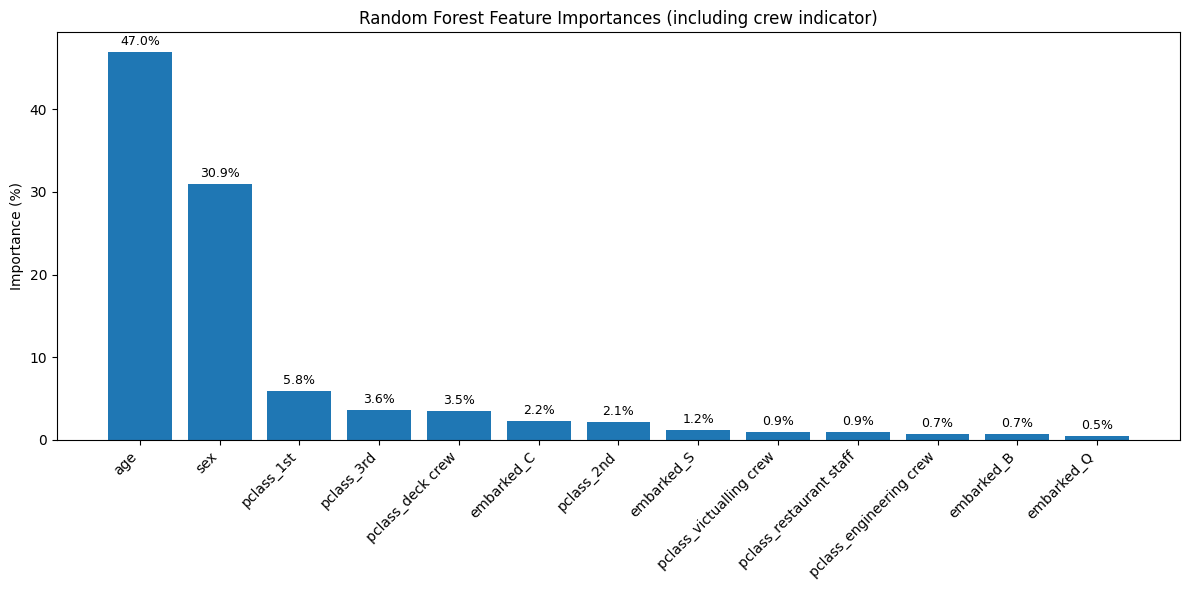

In [174]:
importances = pd.Series(rf.feature_importances_, index=x.columns)
importances = importances.sort_values(ascending=False)
importances_percent = importances * 100

plt.figure(figsize=(12,6))
bars = plt.bar(importances_percent.index, importances_percent.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Importance (%)")
plt.title("Random Forest Feature Importances (including crew indicator)")

for bar, pct in zip(bars, importances_percent.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Conclusion

When crew members are included in the survival analysis, the most important features still appear to be sex and age, regardless of whether the dataset contains only passengers or both passengers and crew.
It does seem that the relative importance of age increases when crew members are included.
Besides this, it appears that people with a, so called, higher status, tend to have an higher survival rate. This is shows in the fact that 1st class passengers, and deck crew both have a above 65% survival rate.